Before Oversampling:
Is Malicious
1    635619
0     86525
Name: count, dtype: int64

After Oversampling:
Is Malicious
0    635619
1    635619
Name: count, dtype: int64

Number of components to explain 95% variance: 5


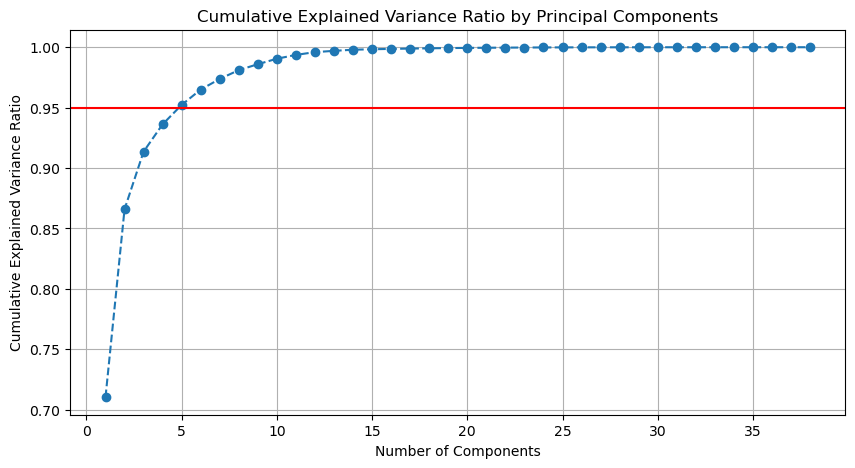

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/opt/conda/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:51:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.95    190417
   Malicious       0.99      0.91      0.95    190955

    accuracy                           0.95    381372
   macro avg       0.96      0.95      0.95    381372
weighted avg       0.96      0.95      0.95    381372


Detailed Metrics:
       Class  Precision    Recall  F1-Score  Support
0     Normal   0.915074  0.995410  0.953553   190417
1  Malicious   0.994984  0.907879  0.949438   190955

ROC-AUC Score: 0.9721

Model saved as xgb_best_model.pkl
Scaler saved as minmax_xgb_scaler.pkl
PCA model saved as pca_xgb_model.pkl


In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# CSV 파일 로드
file_path = 'combined_dataset_with_multi_labels.csv'
df = pd.read_csv(file_path)

# 상관계수 0.3 이상인 피처 리스트
selected_features = [
    'Flow Duration', 'Fwd IAT Total', 'Bwd IAT Total', 'Fwd IAT Max',
    'Bwd IAT Max', 'RST Flag Count', 'Bwd IAT Mean', 'Fwd IAT Mean',
    'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd IAT Min', 'FIN Flag Count',
    'Fwd IAT Std', 'Packet Length Std', 'Bwd Packet Length Std',
    'Average Packet Size', 'Packet Length Max', 'Bwd IAT Std',
    'Packet Length Mean', 'Bwd Packet Length Max'
]

# 데이터프레임에서 피처 선택
df_selected = df[features]

# 로그 변환 적용 (log1p)
df_log_transformed = df_selected.copy()
for feature in features:
    df_log_transformed[feature] = np.log1p(df_log_transformed[feature])  # log(1+x) 적용

# Label에 따라 정상(0)과 비정상(>=1)으로 분류
df['Is Malicious'] = df['Label'].apply(lambda x: 1 if x >= 1 else 0)
X = df_log_transformed
y = df['Is Malicious']

# 오버샘플링 전 데이터 분포 확인
print("Before Oversampling:")
print(y.value_counts())

# SMOTE를 사용하여 오버샘플링
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 오버샘플링 후 데이터 분포 확인
print("\nAfter Oversampling:")
print(pd.Series(y_resampled).value_counts())

# Min-Max 정규화 적용
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_resampled)

# 정규화된 데이터를 데이터프레임으로 변환
df_scaled = pd.DataFrame(X_scaled, columns=features)

# PCA 적용
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 설명된 분산 비율 계산
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# 95% 분산을 설명하는 주성분 수 선택
n_components = np.argmax(cumulative_variance_ratio >= 0.95) + 1
print(f"\nNumber of components to explain 95% variance: {n_components}")

# PCA 재적용 (선택된 주성분 수로)
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# PCA 결과 시각화 (설명된 분산 비율)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.title('Cumulative Explained Variance Ratio by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.savefig('pca_explained_variance.png')
plt.show()

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_resampled, test_size=0.3, random_state=42)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 200, 300],  # 트리 개수
    'max_depth': [3, 5, 7],  # 트리 최대 깊이
    'learning_rate': [0.01, 0.1, 0.2],  # 학습률
    'subsample': [0.7, 0.8, 1.0],  # 데이터 샘플링 비율
    'colsample_bytree': [0.7, 0.8, 1.0]  # 피처 샘플링 비율
}

# RandomizedSearchCV로 하이퍼파라미터 탐색 (시간 절약을 위해 10번만 시도)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=10,  # 10번의 조합 탐색
    scoring='f1_macro',  # F1 스코어 기준
    cv=5,  # 5-fold
    verbose=1,
    random_state=42,
    n_jobs=-1  
)

# 하이퍼파라미터 튜닝 수행
random_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
print("\nBest Parameters:")
print(random_search.best_params_)

# 최적 모델로 예측
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # ROC-AUC를 위한 확률 예측

# 모델 성능 평가
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Malicious']))

# 재현율, F1 스코어 등 상세 지표 추출
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)
metrics_df = pd.DataFrame({
    'Class': ['Normal', 'Malicious'],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print("\nDetailed Metrics:")
print(metrics_df)

# ROC-AUC 점수
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# 모델 저장
model_filename = 'xgb_best_model.pkl'
joblib.dump(best_model, model_filename)
print(f"\nModel saved as {model_filename}")

# 스케일러와 PCA 모델도 저장
scaler_filename = 'minmax_xgb_scaler.pkl'
pca_filename = 'pca_xgb_model.pkl'
joblib.dump(scaler, scaler_filename)
joblib.dump(pca, pca_filename)
print(f"Scaler saved as {scaler_filename}")
print(f"PCA model saved as {pca_filename}")